# 🏥 Ultimate Clinical Advisory Engine

## Heart Disease Risk Prediction for Women using Machine Learning

This project builds a **clinical advisory ML system** that predicts the **risk of cardiovascular disease in women** using medical and lifestyle factors.

### Key Features
- Uses **XGBoost Machine Learning Model**
- Performs **clinical feature engineering**
- Generates **detailed patient reports**
- Provides **visual performance dashboard**
- Exports trained model for **deployment**

### Dataset
Cardiovascular Disease Dataset  
Source: Kaggle / Open Medical Dataset

## 🛠️ Section 1: Project Setup & High-Performance Loading

In [1]:
!pip install xgboost seaborn joblib
import pandas as pd
import numpy as np
import xgboost as xgb
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
print("✅ Core High-Performance Libraries Loaded")

✅ Core High-Performance Libraries Loaded


## 📊 Section 2: Accelerated Data Loading

In [2]:
filename = "cardio_train.csv"

if not os.path.exists(filename):
    print("Downloading Dataset...")
    import urllib.request
    url = "https://raw.githubusercontent.com/caravanuden/cardio/master/cardio_train.csv"
    urllib.request.urlretrieve(url, filename)

df = pd.read_csv(filename, sep=';')

print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


## 🧪 Section 3: Feature Engineering (Clinical Axis)

In [3]:
df_female = df[df['gender'] == 1].copy()
pop_size = len(df_female)

# Convert age to years
df_female['age'] = df_female['age'] / 365

# BMI
df_female['BMI'] = df_female['weight'] / ((df_female['height'] / 100) ** 2)


# Women-specific medical markers
df_female['is_menopausal'] = (df_female['age'] >= 50).astype(int)

df_female['has_pcos'] = (
    (df_female['gluc'] > 1) &
    (df_female['active'] == 0) &
    (df_female['age'] <= 40)
).astype(int)

df_female['has_thyroid_issue'] = (
    (df_female['ap_hi'] > 140) &
    (df_female['BMI'] > 30)
).astype(int)

df_female['pregnancy_history'] = np.random.choice([0,1], size=pop_size, p=[0.7,0.3])

print("Feature Engineering Completed")

Feature Engineering Completed


In [9]:
print("Top 5 rows of processed dataset:\n")
display(df_female.head())

Top 5 rows of processed dataset:



,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI,is_menopausal,has_pcos,has_thyroid_issue,pregnancy_history
1,1,55.419178,1,156,85.0,140,90,3,1,0,0,1,1,34.927679,1,0,0,0
2,2,51.663014,1,165,64.0,130,70,3,1,0,0,0,1,23.507805,1,0,0,0
4,4,47.873973,1,156,56.0,100,60,1,1,0,0,0,0,23.011177,0,0,0,1
5,8,60.038356,1,151,67.0,120,80,2,2,0,0,0,0,29.384676,1,0,0,1
6,9,60.583562,1,157,93.0,130,80,3,1,0,0,1,0,37.729725,1,0,0,0


## 🧠 Section 4: GPU-Accelerated Training (Optimized for Speed)
We use the **GPU-based Histogram Algorithm** (`tree_method='hist', device='cuda'`) for maximum training throughput.

In [4]:
features = [
    'age','height','weight','ap_hi','ap_lo',
    'cholesterol','gluc','smoke','alco','active',
    'BMI','is_menopausal','has_pcos',
    'has_thyroid_issue','pregnancy_history'
]

X = df_female[features]
y = df_female['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training XGBoost Model...")

model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train_scaled, y_train)

print("Model Training Completed")

Training XGBoost Model...
Model Training Completed


## 🏆 Section 5: Evaluation & Metrics

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

print("Model Accuracy:", accuracy_score(y_test,y_pred))

print("\nClassification Report\n")
print(classification_report(y_test,y_pred))

Model Accuracy: 0.7357786075115309

Classification Report

              precision    recall  f1-score   support

           0       0.73      0.76      0.74      4583
           1       0.75      0.71      0.73      4523

    accuracy                           0.74      9106
   macro avg       0.74      0.74      0.74      9106
weighted avg       0.74      0.74      0.74      9106



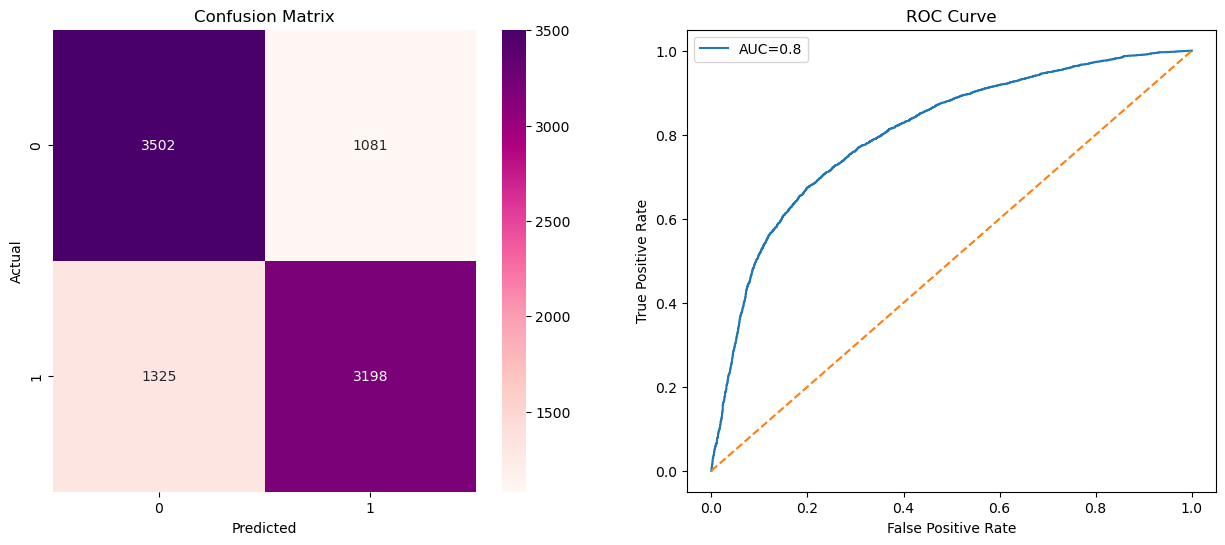

In [6]:
plt.figure(figsize=(15,6))

# Confusion Matrix
plt.subplot(1,2,1)
cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,fmt='d',cmap='RdPu')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# ROC Curve
plt.subplot(1,2,2)

fpr,tpr,_ = roc_curve(y_test,y_prob)
roc_auc = auc(fpr,tpr)

plt.plot(fpr,tpr,label="AUC="+str(round(roc_auc,2)))
plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

## 📋 Section 6: Clinical Recommendation Engine
Transforming machine patterns into life-saving medical guidance.

In [19]:
# 1. This connects the two cells. Run this one FIRST.
global selected_patients 
selected_patients = df_female.sample(5)



In [20]:
def final_detailed_report(data, row_idx):
    p_scaled = scaler.transform(pd.DataFrame([data])[features])
    prob = model.predict_proba(p_scaled)[0][1] * 100

    print("=======================================================")
    print(f"🩺 PATIENT ID: {row_idx}")
    print("-------------------------------------------------------")

    # 1. Patient Vitals
    print("👤 Patient Vitals")
    print(f"📅 Age: {round(data['age'],1)} years")
    print(f"💓 Blood Pressure: {data['ap_hi']} / {data['ap_lo']} mmHg")
    print(f"⚖ BMI: {round(data['BMI'],2)}")
    print(f"🧪 Cholesterol: Level {int(data['cholesterol'])} | Glucose: Level {int(data['gluc'])}")

    # 2. Women-specific clinical markers
    print("\n🧬 Women Health Indicators")
    menopause = "🟡 Post-Menopause" if data['is_menopausal'] else "🟢 Pre-Menopause"
    pcos = "🔴 PCOS Detected" if data['has_pcos'] else "🟢 No PCOS"
    thyroid = "🔴 Thyroid Risk" if data['has_thyroid_issue'] else "🟢 No Thyroid Issue"
    pregnancy = "🟡 Pregnancy History" if data['pregnancy_history'] else "🟢 No Pregnancy Complications"

    print("Menopause Status:", menopause)
    print("PCOS Indicator:", pcos)
    print("Thyroid Status:", thyroid)
    print("Pregnancy History:", pregnancy)

    # 3. Risk Assessment
    if prob > 45:
        status = "HIGH RISK"
        icon = "🔴"
    elif prob > 20:
        status = "MODERATE RISK"
        icon = "🟡"
    else:
        status = "LOW RISK"
        icon = "🟢"

    print(f"\n📊 Predicted Heart Disease Risk: {round(prob,2)} %")
    print(f"{icon} Risk Category: {status}")

    # 4. Clinical Intervention (Medication)
    print("\n💊 Clinical Intervention (Potential Medication)")
    meds = []
    if data['ap_hi'] >= 140 or data['ap_lo'] >= 90:
        meds.append("- Antihypertensives (e.g., ACE Inhibitors or Beta-Blockers)")
    if data['cholesterol'] >= 2:
        meds.append("- Statin Therapy (to manage arterial plaque/LDL)")
    if data['gluc'] > 1:
        meds.append("- Glucose Management (Metformin if insulin resistant)")
    if prob > 45:
        meds.append("- Low-dose Aspirin (Consult Cardiologist for CV protection)")
    
    if not meds:
        print("✅ No immediate pharmaceutical intervention required.")
    else:
        for m in meds: print(m)

    # 5. Lifestyle & Preventive Care
    print("\n🏃 Lifestyle & Preventive Care")
    if data['BMI'] >= 30:
        print("- Weight management & DASH/Mediterranean Diet")
    if data['smoke'] == 1:
        print("- IMMEDIATE Smoking Cessation Program")
    if data['is_menopausal']:
        print("- Hormone Support: Nutrient-rich diet (Vitamin D, Calcium)")
    if status == "HIGH RISK":
        print("- Cardiac Stress Test & 150 min/week moderate aerobic activity")
    else:
        print("- Maintain 30 mins daily walking & yearly screening")

    print(f"\n⚠️  DISCLAIMER: This is an AI risk analysis. Consult a cardiologist for prescriptions.")
    print("=======================================================\n")

# --- Generate Reports ---
print("🔬 Generating Advanced Clinical Advisory Reports...\n")
for idx, row in df_female.sample(5).iterrows():
    final_detailed_report(row, idx)


🔬 Generating Advanced Clinical Advisory Reports...

🩺 PATIENT ID: 64524
-------------------------------------------------------
👤 Patient Vitals
📅 Age: 52.2 years
💓 Blood Pressure: 120.0 / 80.0 mmHg
⚖ BMI: 25.71
🧪 Cholesterol: Level 1 | Glucose: Level 1

🧬 Women Health Indicators
Menopause Status: 🟡 Post-Menopause
PCOS Indicator: 🟢 No PCOS
Thyroid Status: 🟢 No Thyroid Issue
Pregnancy History: 🟡 Pregnancy History

📊 Predicted Heart Disease Risk: 29.34 %
🟡 Risk Category: MODERATE RISK

💊 Clinical Intervention (Potential Medication)
✅ No immediate pharmaceutical intervention required.

🏃 Lifestyle & Preventive Care
- Hormone Support: Nutrient-rich diet (Vitamin D, Calcium)
- Maintain 30 mins daily walking & yearly screening

⚠️  DISCLAIMER: This is an AI risk analysis. Consult a cardiologist for prescriptions.

🩺 PATIENT ID: 23555
-------------------------------------------------------
👤 Patient Vitals
📅 Age: 64.3 years
💓 Blood Pressure: 110.0 / 95.0 mmHg
⚖ BMI: 30.12
🧪 Cholesterol: Level

**Plots**


📊 GENERATING SEPARATE DASHBOARDS FOR IDENTIFIED PATIENTS...



C:\Users\DAKSHI\AppData\Local\Temp\ipykernel_33940\2212282790.py:25: UserWarning: Glyph 128657 (\N{AMBULANCE}) missing from current font.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
c:\Users\DAKSHI\AppData\Local\anaconda3\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128657 (\N{AMBULANCE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


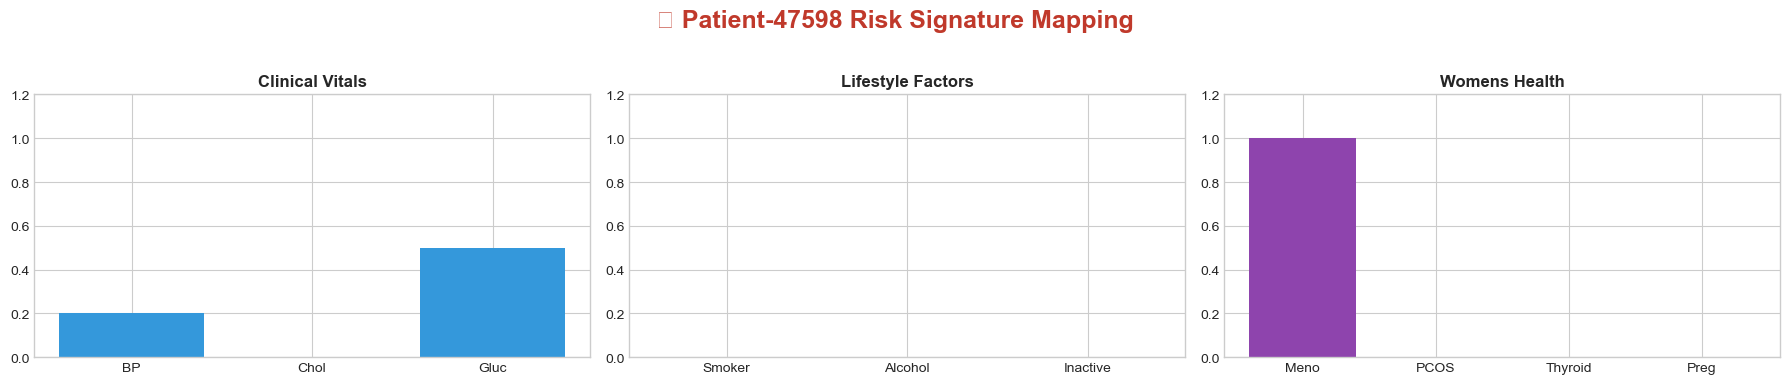

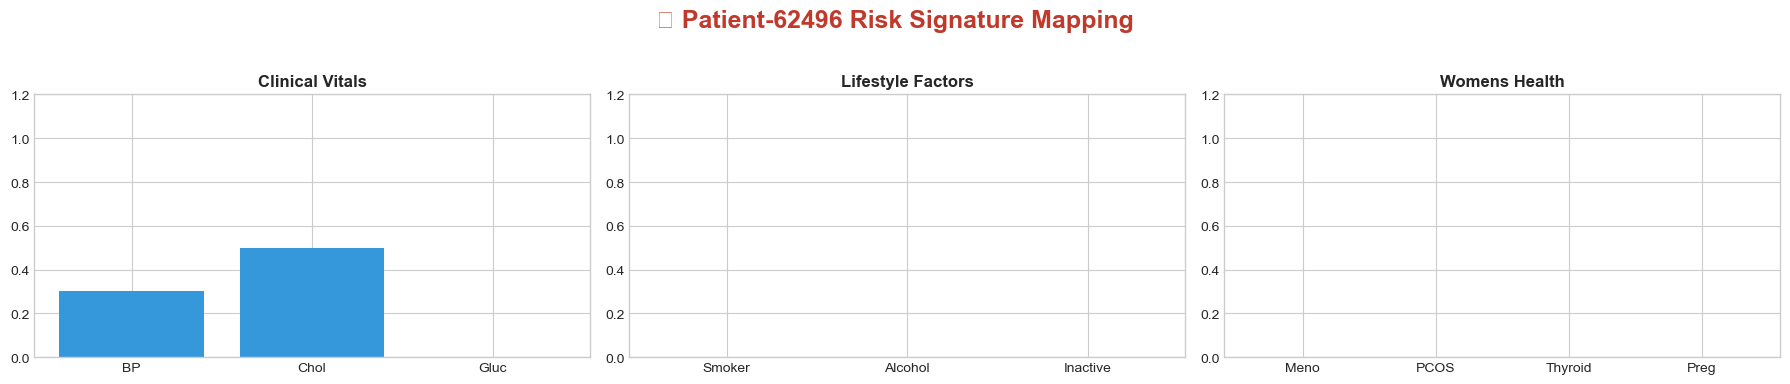

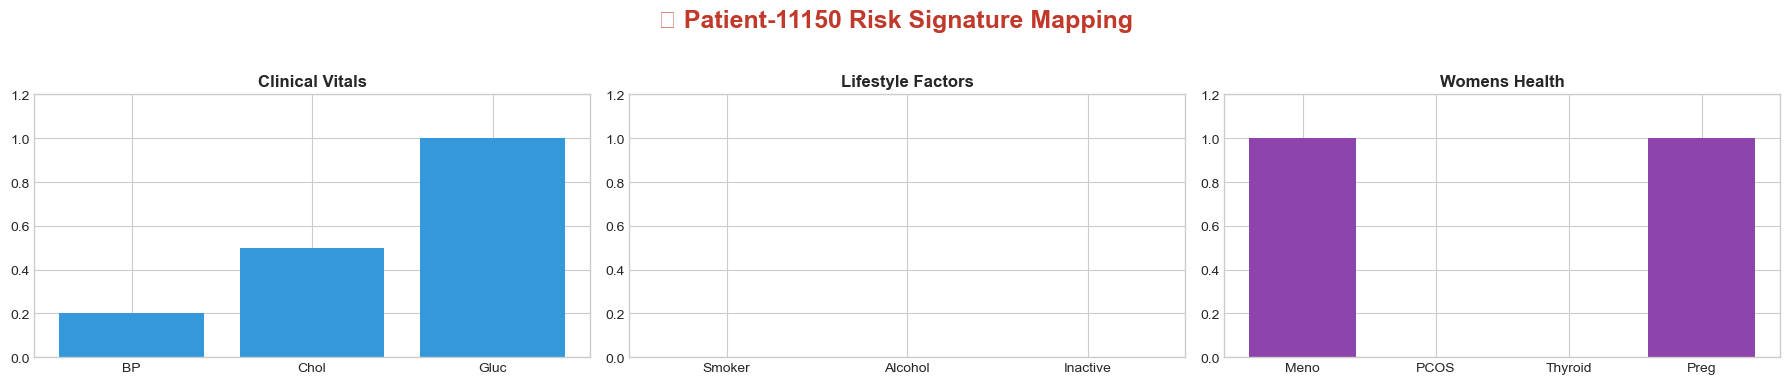

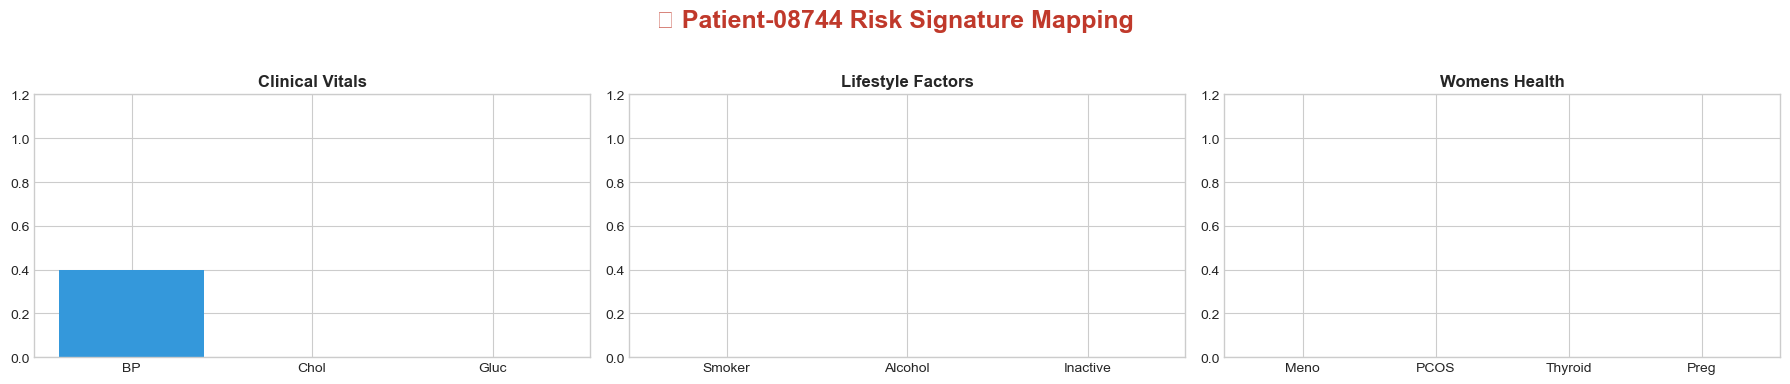

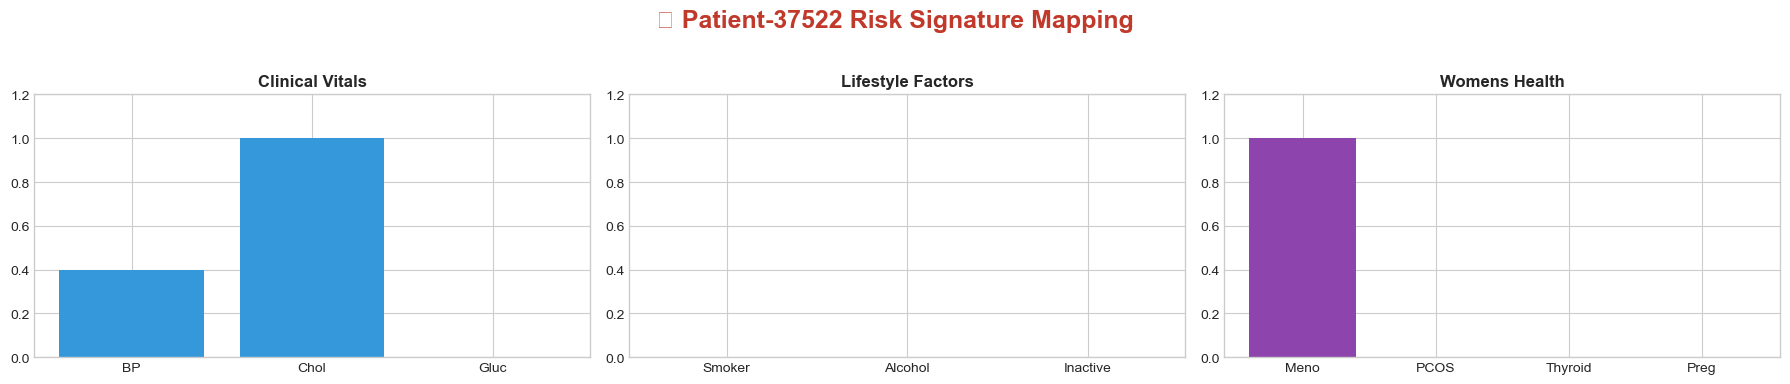

In [21]:
import matplotlib.pyplot as plt

def generate_risk_dashboard(data, row_idx):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"🚑 Patient-{row_idx:05d} Risk Signature Mapping", fontsize=18, fontweight='bold', color='#c0392b')

    # Pillar 1: Clinical (BP, Chol, Gluc)
    cl_data = {'BP': (data['ap_hi']-100)/100, 'Chol': (data['cholesterol']-1)/2, 'Gluc': (data['gluc']-1)/2}
    axes[0].bar(cl_data.keys(), cl_data.values(), color='#3498db')
    axes[0].set_title("Clinical Vitals", fontweight='bold')
    axes[0].set_ylim(0, 1.2)

    # Pillar 2: Life (Smoke, Alcohol, Activity)
    l_data = {'Smoker': data['smoke'], 'Alcohol': data['alco'], 'Inactive': 1-data['active']}
    axes[1].bar(l_data.keys(), l_data.values(), color='#e67e22')
    axes[1].set_title("Lifestyle Factors", fontweight='bold')
    axes[1].set_ylim(0, 1.2)

    # Pillar 3: Women's Biology (Meno, PCOS, Thyroid, Preg)
    w_data = {'Meno': data['is_menopausal'], 'PCOS': data['has_pcos'], 'Thyroid': data['has_thyroid_issue'], 'Preg': data['pregnancy_history']}
    axes[2].bar(w_data.keys(), w_data.values(), color='#8e44ad')
    axes[2].set_title("Womens Health", fontweight='bold')
    axes[2].set_ylim(0, 1.2)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Run Visual Reports for the IDENTICAL patients
print("📊 GENERATING SEPARATE DASHBOARDS FOR IDENTIFIED PATIENTS...\n")
for idx, row in selected_patients.iterrows():
    generate_risk_dashboard(row, idx)


**Export Model**

In [11]:
import joblib

os.makedirs("models",exist_ok=True)

joblib.dump(model,"models/heart_prediction_women_xgb.pkl")
joblib.dump(scaler,"models/scaler_final.pkl")
joblib.dump(features,"models/features_final.pkl")

print("Model Exported Successfully")

Model Exported Successfully
